# Predicting Customer Repurchase Within 6 Months


## 1. IMPORT LIBRARY

In [109]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import *
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier


## 2. IMPORT DATASET

In [110]:
from google.colab import files
uploaded = files.upload()

Saving OnlineRetail.csv to OnlineRetail (2).csv


## 3. Load Dataset

In [111]:
df=pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')
display(df.head())
print(df.shape)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


(541909, 8)


## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is conducted to understand the characteristics of the Online Retail dataset, identify potential data quality issues, and discover customer purchasing patterns. This stage helps reveal trends, anomalies, and relationships between variables that may influence future purchasing behavior. The insights gained from EDA will guide the feature engineering and modeling process.

## Data Understanding

In [112]:
df.info()
display(df.describe(include='all'))
display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,10/31/2011 14:41,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [113]:
cols_to_check = ['Description', 'Country']
for col in cols_to_check:
    print(f"Unique values in {col}: {df[col].unique()}")

Unique values in Description: ['WHITE HANGING HEART T-LIGHT HOLDER' 'WHITE METAL LANTERN'
 'CREAM CUPID HEARTS COAT HANGER' ... 'lost'
 'CREAM HANGING HEART T-LIGHT HOLDER' 'PAPER CRAFT , LITTLE BIRDIE']
Unique values in Country: ['United Kingdom' 'France' 'Australia' 'Netherlands' 'Germany' 'Norway'
 'EIRE' 'Switzerland' 'Spain' 'Poland' 'Portugal' 'Italy' 'Belgium'
 'Lithuania' 'Japan' 'Iceland' 'Channel Islands' 'Denmark' 'Cyprus'
 'Sweden' 'Austria' 'Israel' 'Finland' 'Bahrain' 'Greece' 'Hong Kong'
 'Singapore' 'Lebanon' 'United Arab Emirates' 'Saudi Arabia'
 'Czech Republic' 'Canada' 'Unspecified' 'Brazil' 'USA'
 'European Community' 'Malta' 'RSA']


In [114]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


## Data Cleaning
Narrative: remove missing CustomerID, duplicates, invalid values, create TotalPrice.

In [115]:
df=df.dropna(subset=['CustomerID']).drop_duplicates()
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df=df[(df['Quantity']>0)&(df['UnitPrice']>0)]
df['TotalPrice']=df['Quantity']*df['UnitPrice']
print(df.shape)

(392692, 9)


In [116]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
TotalPrice,0


## Duplikasi

## Outlier Handling (IQR)

In [117]:
def iqr_filter(df, col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

In [118]:
df_before = df.copy() # Capture the state before cleaning and outlier removal

# Cleaning
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df = df.drop_duplicates()
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

# Remove outlier
for c in ["Quantity","UnitPrice"]:
    df = iqr_filter(df, c)

# Baru buat TotalPrice
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [119]:
before = len(df_before)
after = len(df)

print(f"Jumlah data sebelum outlier handling : {before:,}")
print(f"Jumlah data sesudah outlier handling : {after:,}")
print(f"Data yang dihapus                  : {before-after:,}")
print(f"Persentase data dihapus            : {((before-after)/before)*100:.2f}%")

Jumlah data sebelum outlier handling : 392,692
Jumlah data sesudah outlier handling : 333,234
Data yang dihapus                  : 59,458
Persentase data dihapus            : 15.14%


## Statistik Data

In [120]:
print("\n  Statistik Deskriptif:")
print(df[["Quantity","UnitPrice","TotalPrice"]].describe().round(2).to_string())


  Statistik Deskriptif:
        Quantity  UnitPrice  TotalPrice
count  333234.00  333234.00   333234.00
mean        7.55       2.19       12.90
std         6.78       1.55       13.21
min         1.00       0.00        0.00
25%         2.00       1.25        3.90
50%         6.00       1.65       10.14
75%        12.00       2.95       17.40
max        27.00       7.50      178.80


## TOP 10 Country

In [121]:
print("\n  Top 10 Negara berdasarkan jumlah transaksi:")
top_country = df["Country"].value_counts().head(10)
for c, v in top_country.items():
    print(f"    {c:<25}: {v:,}")


  Top 10 Negara berdasarkan jumlah transaksi:
    United Kingdom           : 300,281
    Germany                  : 7,448
    France                   : 6,890
    EIRE                     : 5,443
    Spain                    : 2,040
    Belgium                  : 1,660
    Switzerland              : 1,433
    Portugal                 : 1,252
    Norway                   : 772
    Netherlands              : 617


## Total Sales

In [122]:
print("\n  Total penjualan per bulan:")
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
monthly = df.groupby(["Year","Month"])["TotalPrice"].sum().reset_index()
for _, row in monthly.iterrows():
    print(f"    {int(row.Year)}-{int(row.Month):02d}: Rp {row.TotalPrice:>12,.2f}")


  Total penjualan per bulan:
    2010-12: Rp   284,122.15
    2011-01: Rp   232,767.98
    2011-02: Rp   219,192.88
    2011-03: Rp   285,458.42
    2011-04: Rp   242,420.68
    2011-05: Rp   324,899.44
    2011-06: Rp   290,158.85
    2011-07: Rp   289,068.99
    2011-08: Rp   305,233.84
    2011-09: Rp   480,898.85
    2011-10: Rp   524,843.47
    2011-11: Rp   642,984.88
    2011-12: Rp   177,425.75


## Visualize

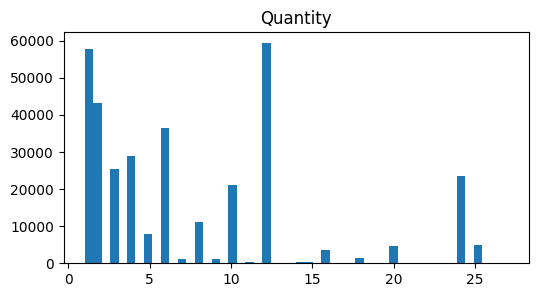

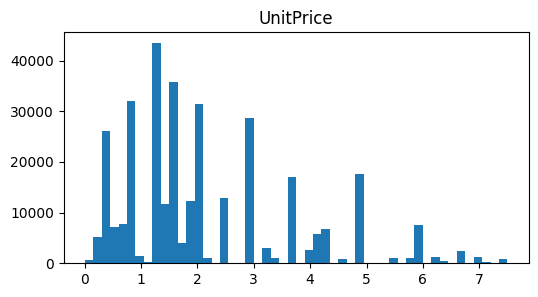

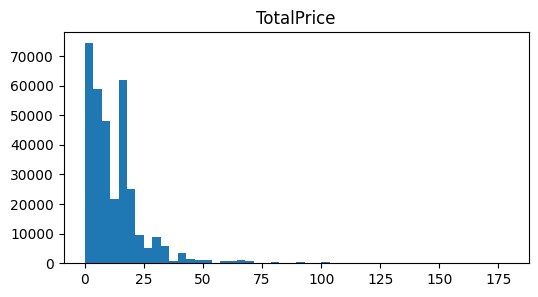

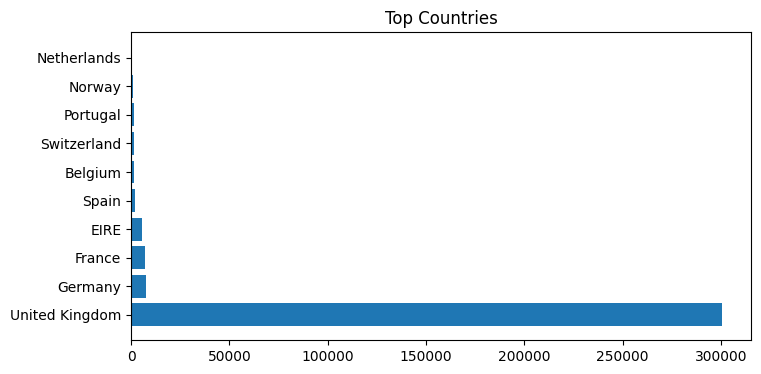

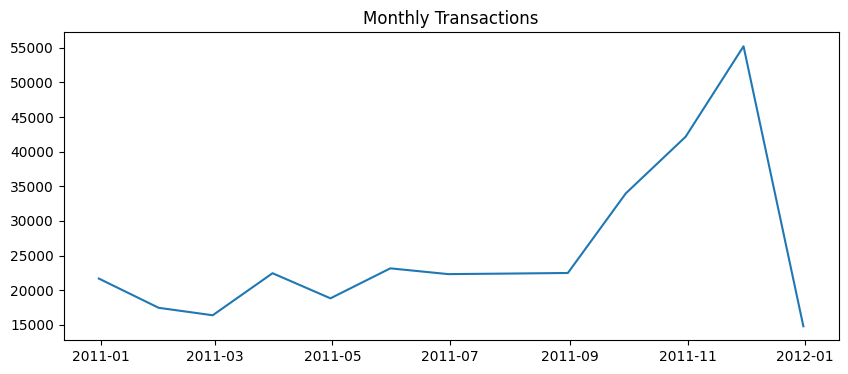

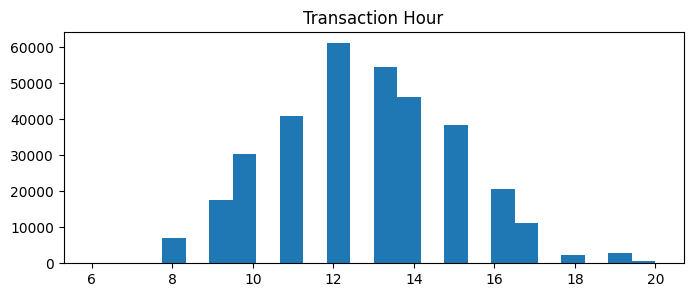

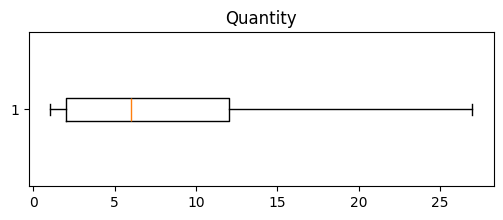

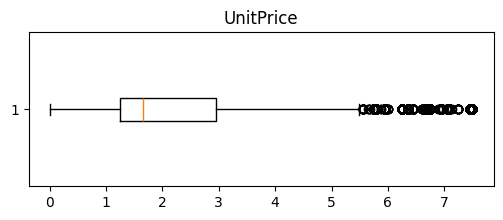

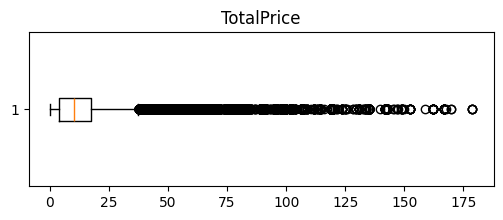

In [123]:
plots=[
('Quantity','hist'),
('UnitPrice','hist'),
('TotalPrice','hist')
]
for col,_ in plots:
    plt.figure(figsize=(6,3))
    plt.hist(df[col],bins=50)
    plt.title(col)
    plt.show()

top=df['Country'].value_counts().head(10)
plt.figure(figsize=(8,4))
plt.barh(top.index,top.values)
plt.title('Top Countries')
plt.show()

monthly=df.set_index('InvoiceDate').resample('M').size()
plt.figure(figsize=(10,4))
plt.plot(monthly.index,monthly.values)
plt.title('Monthly Transactions')
plt.show()

df['Hour']=df['InvoiceDate'].dt.hour
plt.figure(figsize=(8,3))
plt.hist(df['Hour'],bins=24)
plt.title('Transaction Hour')
plt.show()

for c in ['Quantity','UnitPrice','TotalPrice']:
    plt.figure(figsize=(6,2))
    plt.boxplot(df[c],vert=False)
    plt.title(c)
    plt.show()


## 5. Feature Engineering

Feature engineering is performed to transform raw transaction records into customer-level behavioral metrics. Several features such as purchase frequency, monetary value, recency, and average basket size are created to capture customer purchasing habits. These features are expected to improve the model's ability to predict whether a customer will make a purchase within the next six months.

In [124]:
snapshot=df['InvoiceDate'].max()
observation=snapshot-pd.Timedelta(days=182)
history=df[df['InvoiceDate']<=observation].copy()
future=df[df['InvoiceDate']>observation].copy()

recency=(observation-history.groupby('CustomerID')['InvoiceDate'].max()).dt.days.rename('Recency')
frequency=history.groupby('CustomerID')['InvoiceNo'].nunique().rename('Frequency')
monetary=history.groupby('CustomerID')['TotalPrice'].sum().rename('Monetary')
avg_order=(monetary/frequency).rename('AvgOrderValue')
total_qty=history.groupby('CustomerID')['Quantity'].sum().rename('TotalQty')
avg_qty=(total_qty/frequency).rename('AvgQty')
unique_items=history.groupby('CustomerID')['StockCode'].nunique().rename('UniqueItems')
num_months=history.groupby('CustomerID')['InvoiceDate'].agg(lambda x:x.dt.to_period('M').nunique()).rename('NumMonths')
history['Hour']=history['InvoiceDate'].dt.hour
most_hour=history.groupby('CustomerID')['Hour'].agg(lambda x:x.mode().iloc[0]).rename('MostActiveHour')
isuk=history.groupby('CustomerID')['Country'].agg(lambda x:int(x.mode()[0]=='United Kingdom')).rename('IsUK')

target=pd.Series(0,index=history['CustomerID'].unique(),name='WillPurchase')
target.loc[target.index.isin(future['CustomerID'].unique())]=1

customer_df=pd.concat([recency,frequency,monetary,avg_order,total_qty,avg_qty,
unique_items,num_months,most_hour,isuk,target],axis=1).dropna()
display(customer_df.head())

,Recency,Frequency,Monetary,AvgOrderValue,TotalQty,AvgQty,UniqueItems,NumMonths,MostActiveHour,IsUK,WillPurchase
12347.0,0,4,1764.85,441.212500,927,231.750000,69,4,14,0,1
12348.0,66,3,90.20,30.066667,140,46.666667,6,3,19,0,0
12350.0,127,1,294.40,294.400000,196,196.000000,16,1,16,0,0
12352.0,79,4,539.41,134.852500,239,59.750000,21,2,16,0,1
12353.0,21,1,29.30,29.300000,14,14.000000,2,1,17,0,0


## 6. Correlation & Target Distribution

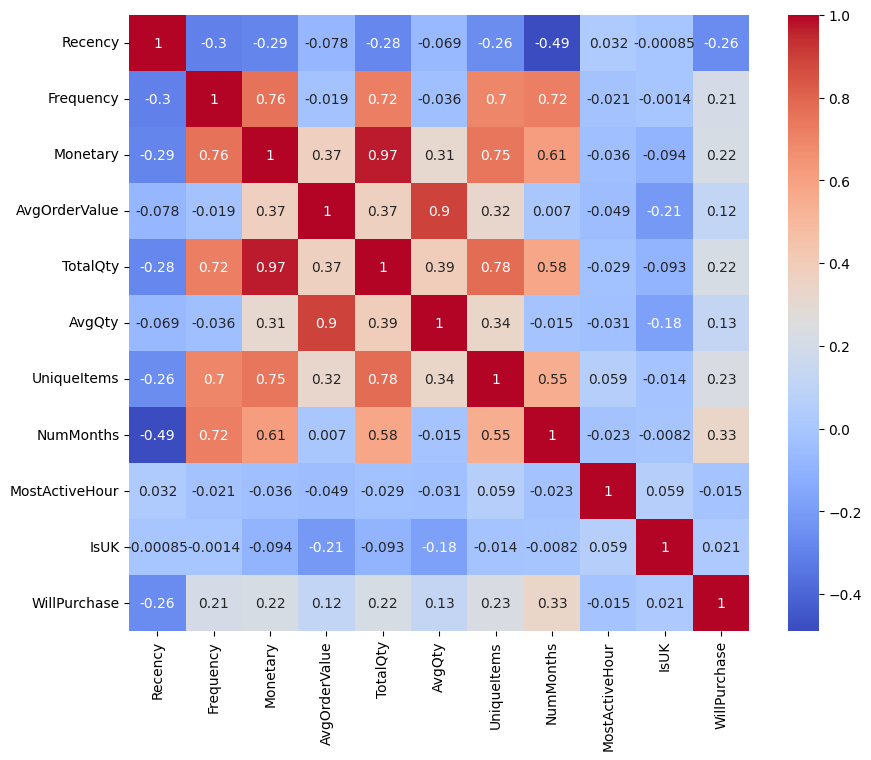

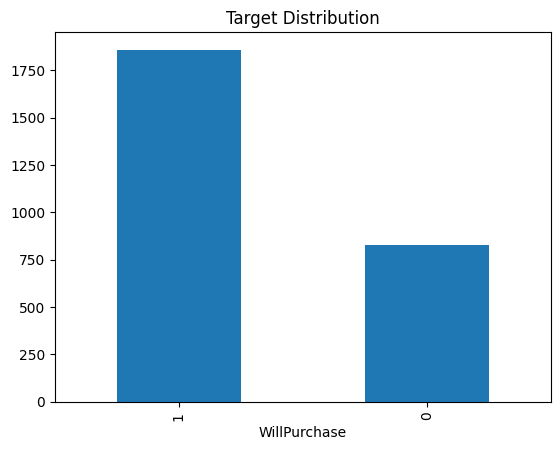

In [125]:
plt.figure(figsize=(10,8))
sns.heatmap(customer_df.corr(),annot=True,cmap='coolwarm')
plt.show()

customer_df['WillPurchase'].value_counts().plot(kind='bar',title='Target Distribution')
plt.show()

## 7. Train-Test Split
Machine learning models are developed to predict customer repurchase behavior within the next six months. The dataset is divided into training and testing sets to evaluate model generalization. Multiple models are trained and compared based on their predictive performance to identify the most suitable approach for supporting customer retention strategies.

### Value Count

In [126]:
print(customer_df['WillPurchase'].value_counts())
print(customer_df['WillPurchase'].value_counts(normalize=True)*100)

WillPurchase
1    1858
0     829
Name: count, dtype: int64
WillPurchase
1    69.147748
0    30.852252
Name: proportion, dtype: float64


### Train-Test Split (80:20)

In [127]:
X=customer_df.drop(columns='WillPurchase')
y=customer_df['WillPurchase']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

### Feature Scaling

In [128]:
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_train)
X_te_sc  = scaler.transform(X_test)

FEATURES = X.columns # Define FEATURES
label_map = {0: 'No Purchase', 1: 'Will Purchase'} # Define label_map

print(f" Fitur: {FEATURES.tolist()}")
print(f" Total sampel  : {len(X):,}")
print(f" Training set  : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)")
print(f" Test set      : {len(X_test):,} ({len(X_test)/len(X)*100:.0f}%)")
print(f"\n  Distribusi kelas di train/test:")
for k, v in label_map.items():
    tr = (y_train == k).sum() # Corrected yc_train to y_train
    te = (y_test  == k).sum()  # Corrected yc_test to y_test
    print(f"    {v:<8}: train={tr:3d}  test={te:3d}")

 Fitur: ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'TotalQty', 'AvgQty', 'UniqueItems', 'NumMonths', 'MostActiveHour', 'IsUK']
 Total sampel  : 2,687
 Training set  : 2,149 (80%)
 Test set      : 538 (20%)

  Distribusi kelas di train/test:
    No Purchase: train=663  test=166
    Will Purchase: train=1486  test=372


In [129]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Distribusi kelas setelah SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Distribusi kelas setelah SMOTE:
WillPurchase
1    1486
0    1486
Name: count, dtype: int64


## 8. Model Training & Hyperparameter Tuning

Training Model

In [130]:
models={}
lr=GridSearchCV(Pipeline([('scaler',StandardScaler()),
('model',LogisticRegression(max_iter=1000))]),
{'model__C':[0.01,0.1,1,10]},cv=cv,scoring='f1')
lr.fit(X_train,y_train);models['Logistic Regression']=lr.best_estimator_

dt=GridSearchCV(DecisionTreeClassifier(random_state=42),
{'max_depth':[3,5,7,10],'min_samples_split':[2,5,10]},cv=cv,scoring='f1')
dt.fit(X_train,y_train);models['Decision Tree']=dt.best_estimator_

knn=GridSearchCV(Pipeline([('scaler',StandardScaler()),('model',KNeighborsClassifier())]),
{'model__n_neighbors':[3,5,7,9,11]},cv=cv,scoring='f1')
knn.fit(X_train,y_train);models['KNN']=knn.best_estimator_

ann=GridSearchCV(Pipeline([('scaler',StandardScaler()),
('model',MLPClassifier(max_iter=1000,random_state=42))]),
{'model__hidden_layer_sizes':[(32,),(64,),(64,32)],
'model__alpha':[0.0001,0.001,0.01]},cv=cv,scoring='f1')
ann.fit(X_train,y_train);models['ANN']=ann.best_estimator_

In [131]:
hasil = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'KNN', 'ANN'],
    'Best F1 CV': [lr.best_score_,
                   dt.best_score_,
                   knn.best_score_,
                   ann.best_score_]
})

print(hasil.sort_values(by='Best F1 CV', ascending=False))

                 Model  Best F1 CV
0  Logistic Regression    0.814292
3                  ANN    0.795400
1        Decision Tree    0.789517
2                  KNN    0.781755


## 9. Evaluation

The trained models are evaluated using several performance metrics to assess their predictive capability. Evaluation focuses on classification accuracy, precision, recall, F1-score, and other relevant metrics to determine how effectively the models identify customers who are likely to make future purchases.


 Logistic Regression
              precision    recall  f1-score   support

           0       0.54      0.19      0.28       166
           1       0.72      0.93      0.81       372

    accuracy                           0.70       538
   macro avg       0.63      0.56      0.54       538
weighted avg       0.67      0.70      0.65       538



<Figure size 600x500 with 0 Axes>

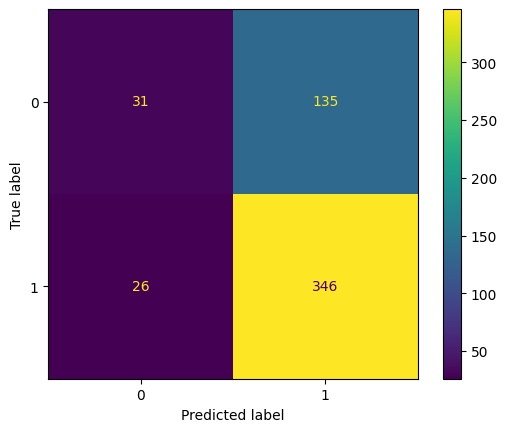

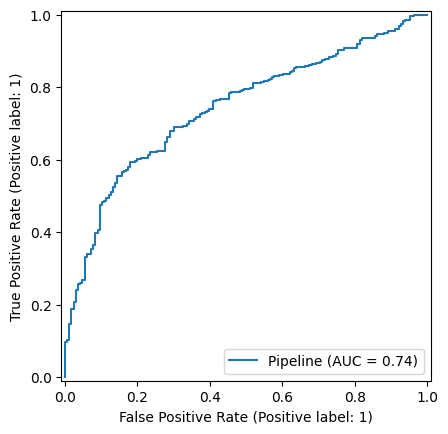


 Decision Tree
              precision    recall  f1-score   support

           0       0.51      0.40      0.45       166
           1       0.76      0.83      0.79       372

    accuracy                           0.70       538
   macro avg       0.63      0.62      0.62       538
weighted avg       0.68      0.70      0.69       538



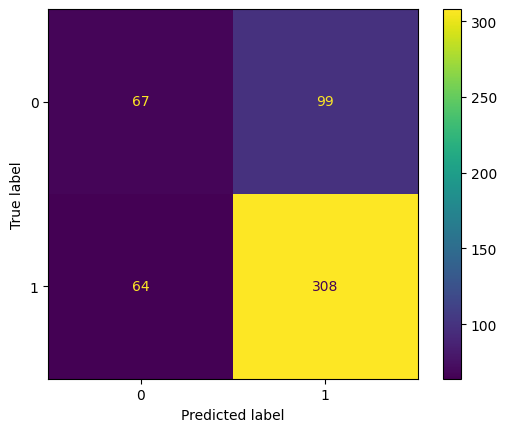

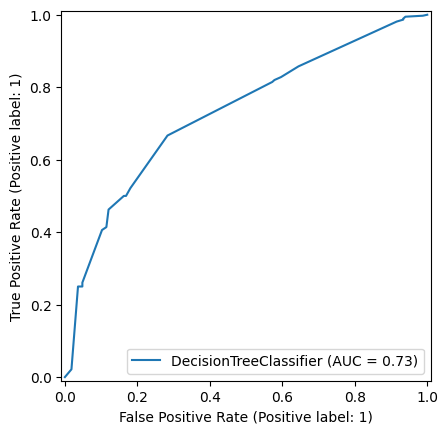


 KNN
              precision    recall  f1-score   support

           0       0.48      0.37      0.41       166
           1       0.74      0.82      0.78       372

    accuracy                           0.68       538
   macro avg       0.61      0.59      0.60       538
weighted avg       0.66      0.68      0.67       538



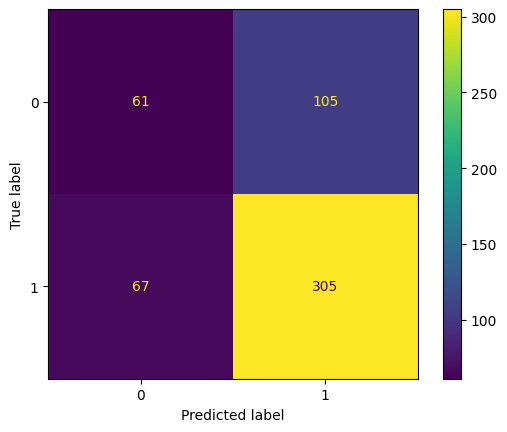

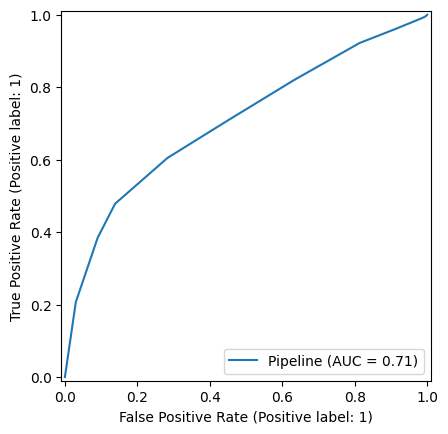


 ANN
              precision    recall  f1-score   support

           0       0.52      0.39      0.44       166
           1       0.75      0.84      0.80       372

    accuracy                           0.70       538
   macro avg       0.64      0.61      0.62       538
weighted avg       0.68      0.70      0.69       538



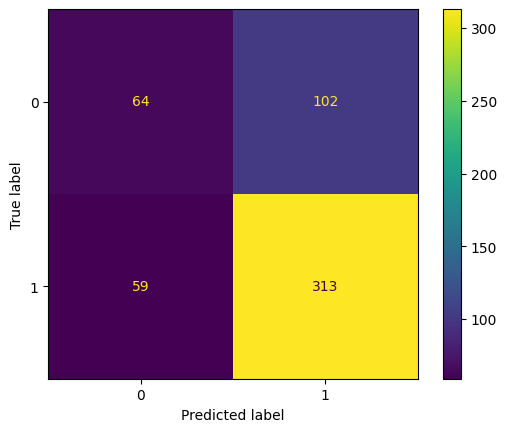

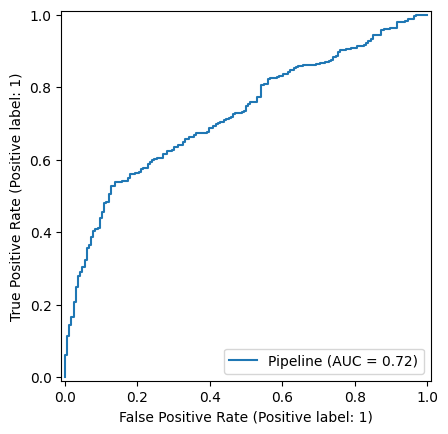

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.700743,0.719335,0.930108,0.811254,0.741239
3,ANN,0.700743,0.754217,0.841398,0.795426,0.724041
1,Decision Tree,0.697026,0.756757,0.827957,0.790757,0.729191
2,KNN,0.680297,0.743902,0.819892,0.780051,0.705605


In [132]:
results=[]
plt.figure(figsize=(6,5))
for name,m in models.items():
    pred=m.predict(X_test)
    prob=m.predict_proba(X_test)[:,1]
    results.append({
        'Model':name,
        'Accuracy':accuracy_score(y_test,pred),
        'Precision':precision_score(y_test,pred),
        'Recall':recall_score(y_test,pred),
        'F1':f1_score(y_test,pred),
        'ROC_AUC':roc_auc_score(y_test,prob)
    })
    print('\n',name)
    print(classification_report(y_test,pred))
    ConfusionMatrixDisplay.from_predictions(y_test,pred)
    plt.show()
    RocCurveDisplay.from_estimator(m,X_test,y_test)
    plt.show()
comparison=pd.DataFrame(results).sort_values('F1',ascending=False)
display(comparison)


## 10. Purchase Probability

In [133]:
customer_df['PurchaseProbability'] = ann.predict_proba(X)[:,1]

customer_df.sort_values(
    by='PurchaseProbability',
    ascending=False
).head(10)

,Recency,Frequency,Monetary,AvgOrderValue,TotalQty,AvgQty,UniqueItems,NumMonths,MostActiveHour,IsUK,WillPurchase,PurchaseProbability
14911.0,0,64,24450.00,382.031250,13837,216.203125,769,7,12,0,1,1.000000
13089.0,3,44,17104.76,388.744545,10657,242.204545,388,7,11,1,1,0.999999
14298.0,8,27,12762.83,472.697407,9235,342.037037,381,7,12,1,1,0.999999
13081.0,35,7,9933.93,1419.132857,6852,978.857143,326,5,16,1,1,0.999944
17841.0,0,50,9512.77,190.255400,5630,112.600000,727,7,14,1,1,0.999853
15039.0,2,26,9314.23,358.239615,4809,184.961538,272,7,11,1,1,0.999751
17735.0,4,10,5709.85,570.985000,3717,371.700000,211,7,10,1,1,0.999453
14156.0,3,16,7516.96,469.810000,3038,189.875000,273,6,14,0,1,0.999230
12681.0,4,13,6480.88,498.529231,4114,316.461538,185,6,11,0,1,0.999074
12921.0,2,15,5186.28,345.752000,3329,221.933333,133,6,13,1,1,0.998654


In [134]:
customer_df['Segment'] = pd.cut(
    customer_df['PurchaseProbability'],
    bins=[0,0.5,0.8,1],
    labels=['Low','Medium','High']
)
print(customer_df['Segment'].value_counts())

Segment
Medium    1163
High       936
Low        588
Name: count, dtype: int64


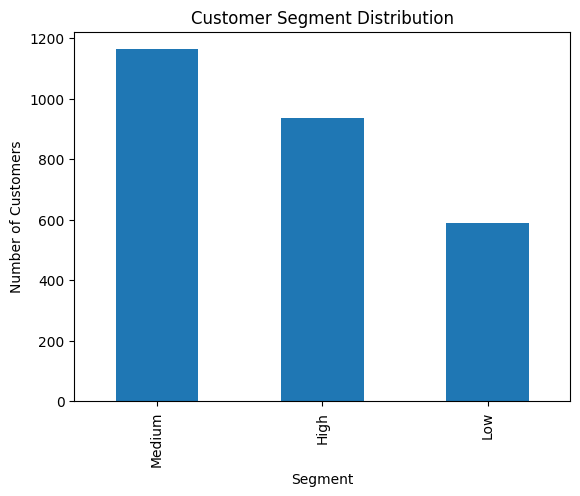

In [135]:
import matplotlib.pyplot as plt

customer_df['Segment'].value_counts().plot(kind='bar')

plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.show()

## Final Conclusion

In [136]:
best = comparison.iloc[0]

conclusion = f"""
Model terbaik adalah {best['Model']}.

Performance Metrics:

Accuracy  : {best['Accuracy']:.4f}
Precision : {best['Precision']:.4f}
Recall    : {best['Recall']:.4f}
F1-Score  : {best['F1']:.4f}
ROC-AUC   : {best['ROC_AUC']:.4f}

Therefore, this model is selected as the final predictive
model because it demonstrates the strongest balance between
classification performance and discriminative ability.
"""

print(conclusion)


Model terbaik adalah Logistic Regression.

Performance Metrics:

Accuracy  : 0.7007
Precision : 0.7193
Recall    : 0.9301
F1-Score  : 0.8113
ROC-AUC   : 0.7412

Therefore, this model is selected as the final predictive
model because it demonstrates the strongest balance between
classification performance and discriminative ability.



### Feature Importance

<Figure size 800x500 with 0 Axes>

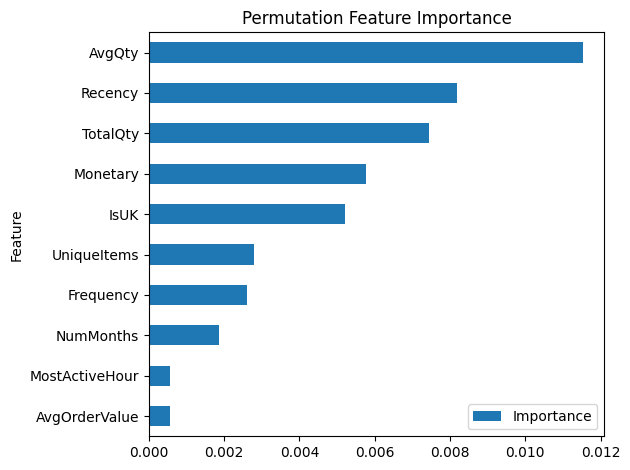

In [137]:
from sklearn.inspection import permutation_importance

best_model_name = best['Model']
best_model = models[best_model_name]

perm_importance = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_importance.importances_mean
})

plt.figure(figsize=(8,5))
importance.sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh"
)
plt.title("Permutation Feature Importance")
plt.tight_layout()
plt.show()